# Divisor Approach Tutorial

This notebook demonstrates how to use smfBursts to perform divisor based $\mathrm{H^{2}MM}$ analysis,
as seen in [Harris 2022](https://doi.org/10.1016/j.bpr.2022.100071).

$\mathrm{\alpha Syn}$ data can be downloaded from: https://zenodo.org/records/4587698

We start with standard imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tables as tb

import smfbursts as smf
import H2MMbursts as bhm

## Import and regularize data

Load data, and check loaded excitation window settings

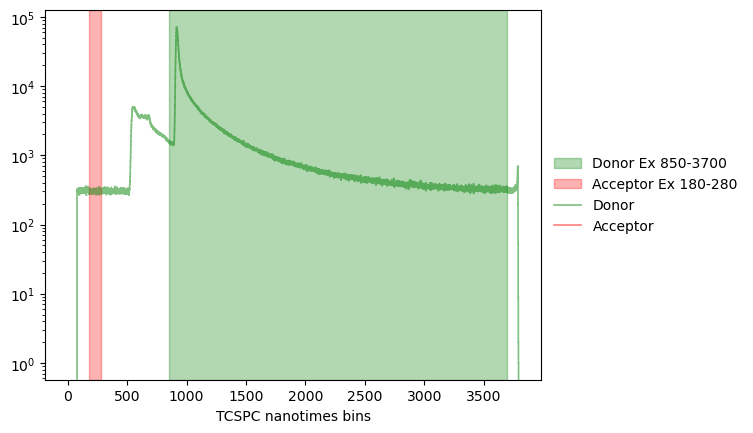

In [2]:
raw = smf.photonHDF5.load('data/aSyn_140C_Cy3_25pM_PIFE_170uW_20MHz_1_SPC630.hdf5')
smf.plot.alternation_hist(raw)

Modif incorrect settings, and replot excitation histogram.

> **Note**
>
> This cell should not be necessary when using new data.
> The example data was converted to photonHDF5 trying to make it smFRET compatible for FRETBursts.
> smfBursts does no assume 2 detector streams,
> and can therefore interpret correctly formated single stream photon-HDF5 measurements.

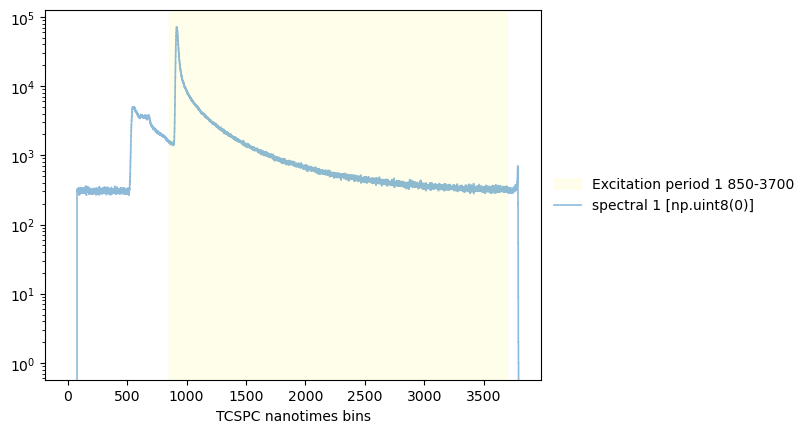

In [3]:
# remove extraneous parameters incorrectly inserted in HDF5 file
raw.photon_data[0].meas_specs['detectors_specs'].pop('spectral_ch2')
raw.photon_data[0].meas_specs.pop('alex_excitation_period2')
raw.setup['detection_wavelengths'] = np.array([5.85e-7])
raw.setup['excitation_alternated'] = np.array([0,], dtype=np.uint8)
raw.setup['excitation_cw'] = np.array([0,], dtype=np.uint8)
raw.setup['excitation_wavelengths'] = np.array([5.32e-07,])
raw.setup['laser_repetition_rates'] = raw.setup['laser_repetition_rates'][:1]
raw.setup['num_spectral_ch2'] = 1
# replot to confirm correct disply
smf.plot.alternation_hist(raw)

In [4]:
data = smf.photonHDF5.regularize_dets(raw)

Create background analysis parameters, and plot to verify appropriate data.

Text(0.5, 1.0, 'Interphoton times')

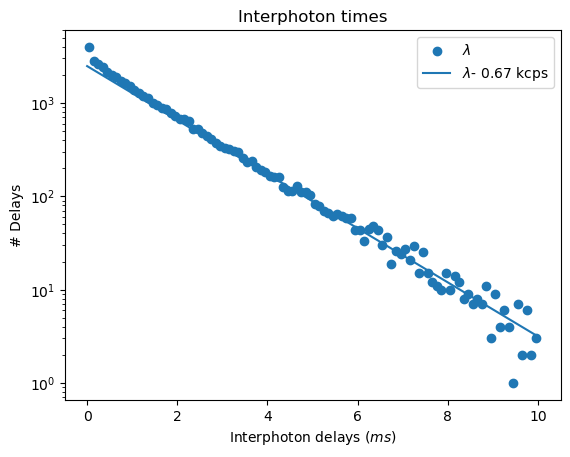

In [5]:
prd = smf.Param(smf.Periods, detdef=data.detdef, period=60.0)
bg = smf.Param(smf.BG, base=prd, func=smf.bg.exp_mlefit, 
               auto_threshold=True, tail_min=5e-4)

smf.plot.hist_interphoton(data, bg, streams=smf.PhSel('0ex0em'))
plt.title("Interphoton times")

Setting the IRF threshold. For computation of mean nanotimes,
a threshold for the IRF must be set:

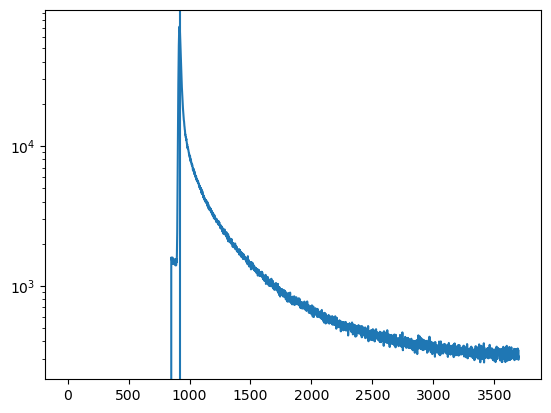

In [6]:
irfthresh = 925
nhist = np.bincount(data.nanos)
# alternative heuristic for irfthresh, typically best is slightly longer than max
# irfthresh = np.argmax(nhist) 
plt.semilogy(nhist)
plt.axvline(irfthresh)

In [7]:
data.irf_thresh[smf.PhSel('0ex0em')] = irfthresh

## Burst Search and selection

Now that the background has been characterized,
the burst search is defined, and a dictionary is built of important `Columns`.


In [8]:
brst = {'bursts':smf.Param(smf.Bursts, m=10, F=6.0, bg=bg)}
brst['nph'] = smf.Param(smf.NphBG, base=brst['bursts'], bg=bg)
brst['Nph_raw'] = smf.Column(brst['bursts'], 'nph_raw', smf.PhSel('0ex0em'))
brst['Nph_bg'] = smf.Column(brst['nph'], 'nph_bg', smf.PhSel('0ex0em'))
brst['Dur'] = smf.Column(brst['bursts'], 'dur', ('istarttime', 'istoptime'))
brst['MR10'] = smf.Column(brst['bursts'], 'max_rate', (smf.PhSel('0ex0em'), 10))
brst['Nanohist'] = smf.Column(brst['bursts'], 'nanohist', (smf.PhSel('0ex0em'), True))
brst['Nanomean'] = smf.Column(brst['bursts'], 'nanomean', smf.PhSel('0ex0em'))
brst['Nanomean_bg'] = smf.Column(brst['nph'], 'nanomean_bg', (smf.PhSel('0ex0em'), 'thresh'))

### Burst Selection

Now we plot the imporant columns to set thresholds for burst selection.
Vertical lines show thresholds, the value is set as a variable at the start of the cell.
This can be varied to find the optimal value.

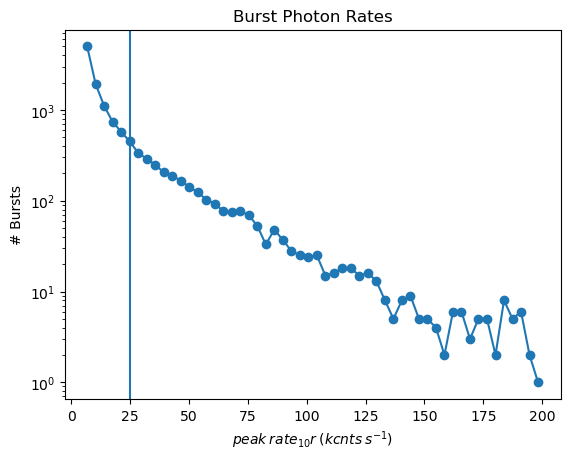

In [9]:
pkrt = 25000

smf.plot.hist_line(data, brst['MR10'], bins=np.linspace(5,200,55), 
                   rescale=3, marker='o', include_unit=True)
plt.yscale('log')
plt.title("Burst Photon Rates")
plt.axvline(pkrt/1e3) # / 1e-3 because rescale = 3, ie displayed values are kcnts

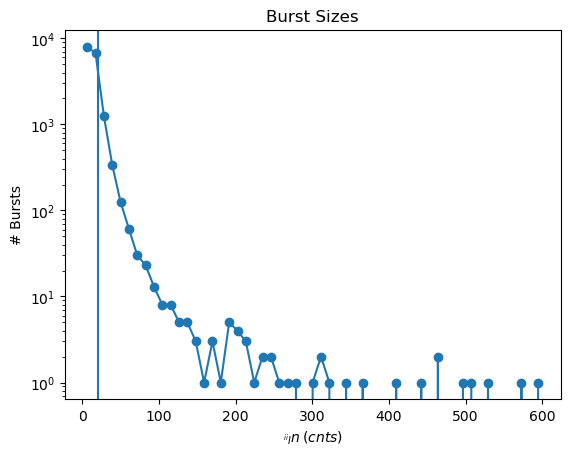

In [10]:
bsz = 20
smf.plot.hist_line(data, brst['Nph_bg'], bins=np.linspace(1,600,56), 
                   marker='o', include_unit=True)
plt.yscale('log')
plt.title("Burst Sizes")
plt.axvline(bsz)

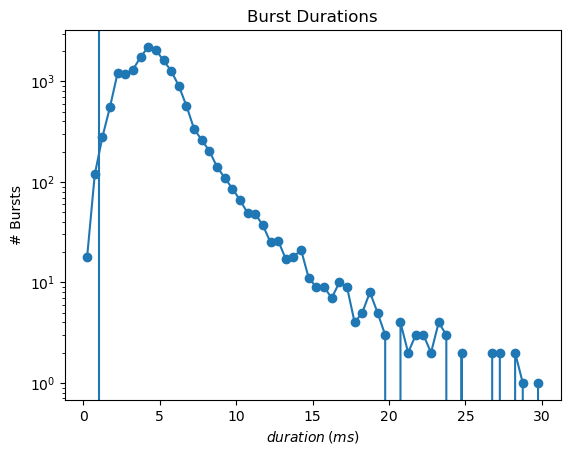

In [11]:
mindur = 1e-3
smf.plot.hist_line(data, brst['Dur'], bins=np.linspace(0,30,61), 
                   rescale=-3, marker='o', include_unit=True)
plt.yscale('log')
plt.title("Burst Durations")
plt.axvline(mindur/1e-3) # / 1e-3 because rescale = 3, ie displayed values are ms

Now that the thresholds have been set, we can build a gate to use in further anlaysis:

In [12]:
gate = smf.make_geq_gate(brst['MR10'], pkrt)
gate &= smf.make_geq_gate(brst['Nph_bg'], bsz)
gate &= smf.make_geq_gate(brst['Dur'], mindur)

brst = smf.fretfactory.apply_gate(brst, gate)

Now lets see the lifetime distribution of our selected bursts:

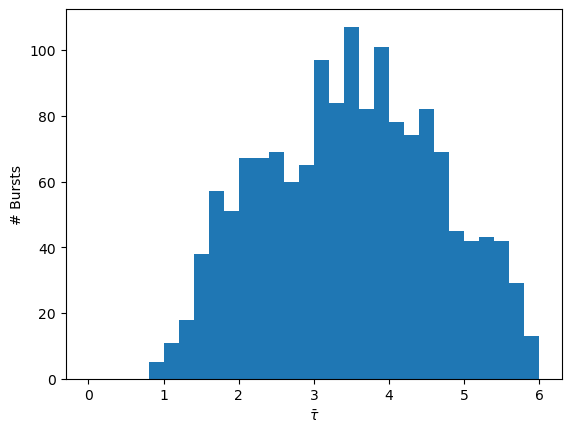

In [13]:
smf.plot.hist_bar(data, brst['Nanomean'], bins=np.arange(0.0,6.1,0.2), rescale=-9);

## Divisor based analysis

Now we can proceed to the divisor based analysis.

### Define divisors

The first step is to define the divisors used.

There are several methods that can be used, the `bhm.fretfactory.make_divisors` function
allows for creation of divisor schemes that equally distribute photons between divisors.
If no prior knowledge about the system is know, this is often the best method.
However, if there states with known lifetimes, selecting divisor that maximize the difference
in emission probabilities between states will be more ideal.

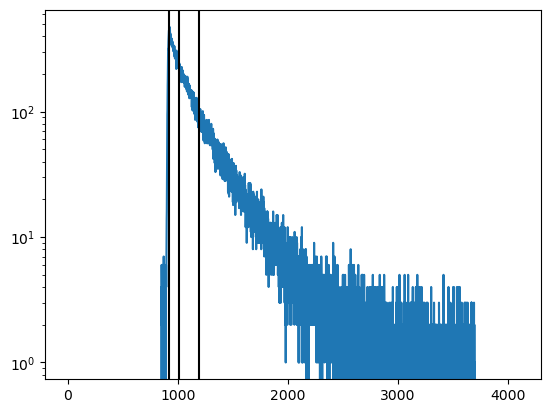

In [14]:
streams = (smf.PhSel('all'), ) # streams, single stream for single chromophore
ndivs = (1, ) # 2 divisors in only stream in model
# Generate divisors
divs = bhm.fretfactory.make_divisors(data, brst['bursts'], 
                                     ndivs=2, streams=streams,
                                     include_irf_thresh=True)
                                     
# plot decay
plt.semilogy(data.get_column(brst['Nanohist']).sum(axis=0))
# plot locations of divisors
for dv in divs[0]:
    plt.axvline(dv, c='k')

### Run optimization

Now that the divisor scheme is established, we can now optimize the models with the divisor scheme
with `bhm.ntdivStatepath.optimize_models`

In [15]:
statepaths = bhm.ntdivStatePath.optimize_models(
    data, brst['bursts'], streams=streams, divs=divs
)

The model converged after 2 iterations
The model converged after 161 iterations
The model converged after 713 iterations
Optimization reached maximum number of iterations


And plot the statistical discriminators

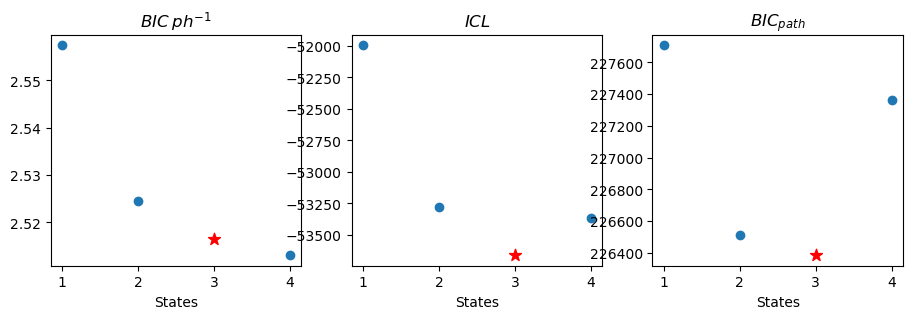

In [16]:
fig, ax = plt.subplots(1,3, figsize=(11,3))
bhm.plot.scatter_BICph(data, statepaths, ax=ax[0], thresh=0.005)
bhm.plot.scatter_ICL(data, statepaths, ax=ax[1])
bhm.plot.scatter_pathBIC(data, statepaths, ax=ax[2]);

It looks like the 3 state model is the best in this example.
We will still make a set of dwells parameters for each model.

In [17]:
dwells = [{'dwells':smf.Param(bhm.Dwells, statepath=sp)} for sp in statepaths]
for dwell in dwells:
    dwell['Nanomean'] = smf.Column(dwell['dwells'], 'nanomean', smf.PhSel('all'))
    dwell['Dur'] = smf.Column(dwell['dwells'], 'dur')
    dwell['Nanohist'] = smf.Column(dwell['dwells'], 'nanohist', smf.PhSel('all'))
    dwell['State'] = smf.Column(dwell['dwells'], 'state')

Now we can examine the results of the model, plotting histograms per state of nanotimes

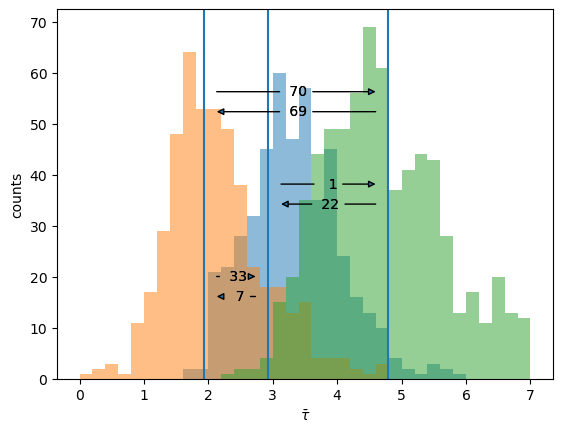

In [18]:
ns = 3
for i in range(ns):
    dw = dwells[ns-1]
    smf.plot.hist_bar(data, dw['Nanomean'], bins=np.arange(0,7.1, 0.2),
                      alpha=0.5, rescale=-9, gate=smf.make_isin_gate(dw['State'], i))
# plot bars
bhm.plot.hist_model(dwells[ns-1]['Nanomean'], data=data, rescale=-9)
bhm.plot.hist_model_trans_arrows(dwells[ns-1]['Nanomean'], data=data, rescale=-9);

And now that we are done, don't forget to print the ciations:

In [19]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Müller, B. K., Zaychikov, E., Bräuchle, C. & Lamb, D. C. Pulsed interleaved
    excitation. Biophysical Journal 89, 3508–3522 (2005).
3. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison
    between theory and experiments. Journal of Physical Chemistry B 110,
    22103–22124 (2006).
4. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
5. Harris, P. D. & Lerner, E. Identification and quantification of within-burst
    dynamics in singly labeled single-molecule fluorescence lifetime
    experiments. Biophysical Reports 2, 100071 (2022).
6. Pirchi, M. et al. Photon-by-Photon Hidden Markov M

Thus the basic single channel lifetime analysis tutorial is concluded.
Much more can be done in visualizing different parameters like durations, max rates etc.

It is also recomended to try different divisor schemes to ensure the results are not artefactual.